<a href="https://www.kaggle.com/code/lukaspanos/mnist-log-reg-snn-cnn?scriptVersionId=344986829" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
test = pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv')

print(train.shape)   # (42000, 785) — label + 784 pixels
print(train['label'].value_counts().sort_index())

(42000, 785)
label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


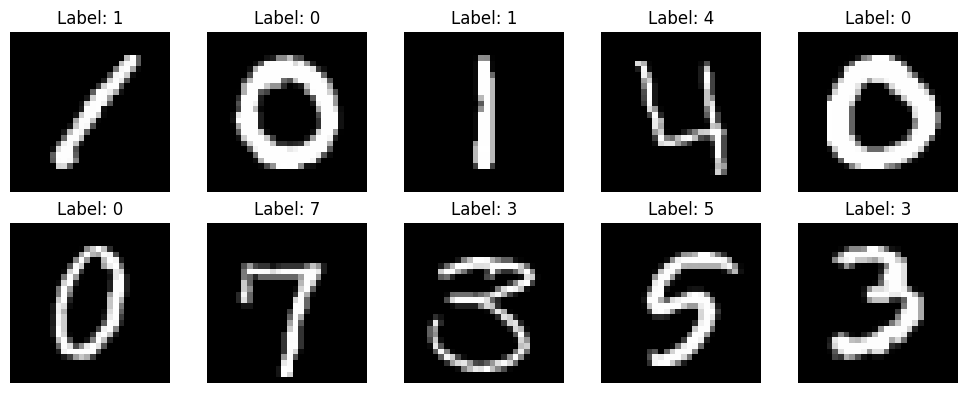

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img = train.drop(columns=['label']).iloc[i].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {train['label'].iloc[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [3]:
X = train.drop(columns=['label']) / 255.0   # scale pixels to 0-1
y = train['label']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

print(f"Accuracy: {accuracy_score(y_test, logreg.predict(X_test)):.4f}")

Accuracy: 0.9137


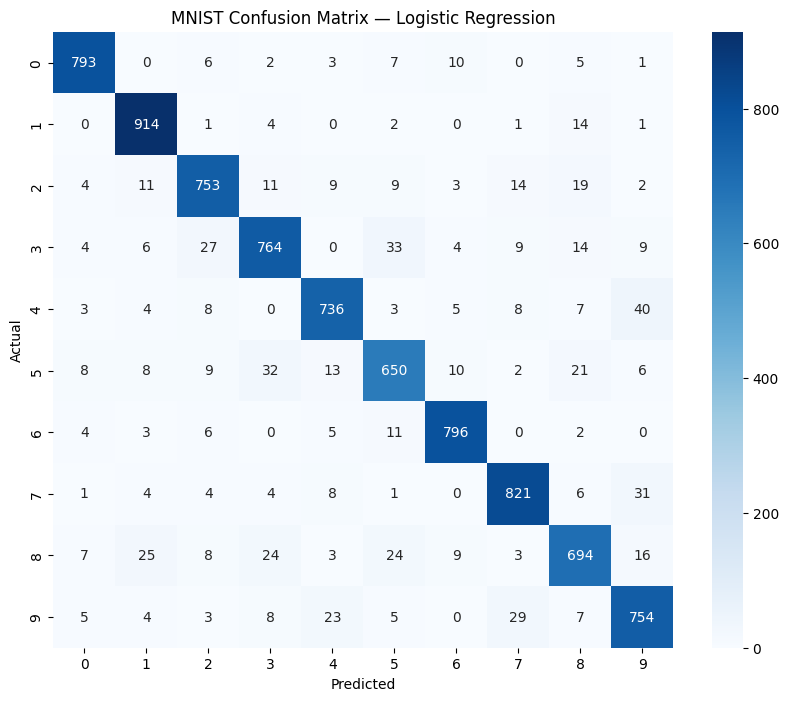

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = logreg.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('MNIST Confusion Matrix — Logistic Regression')
plt.show()

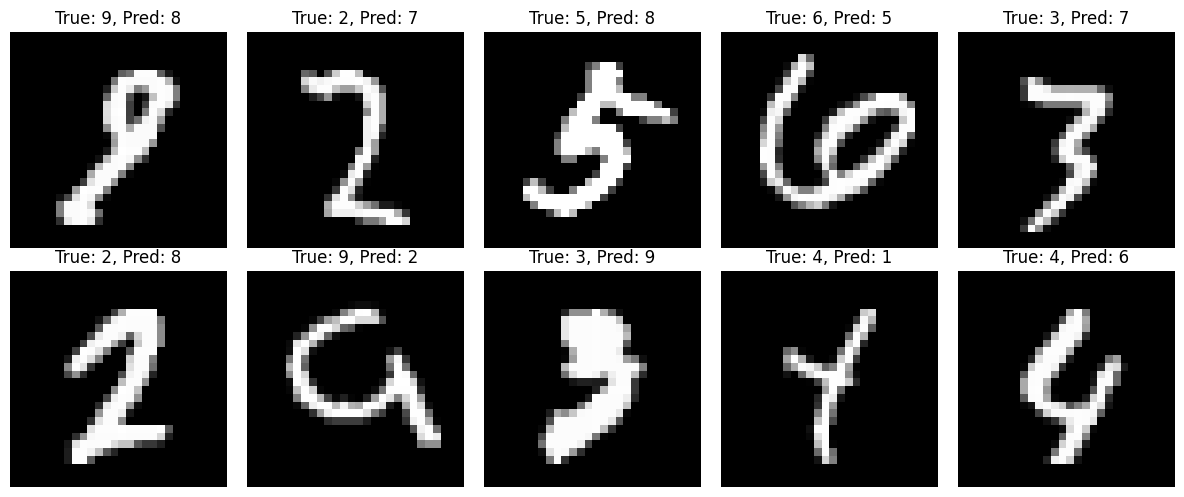

In [6]:
wrong = np.where(y_pred != y_test.values)[0]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = wrong[i]
    img = X_test.iloc[idx].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"True: {y_test.values[idx]}, Pred: {y_pred[idx]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [7]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-26 01:18:13.642539: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train.values, y_train.values,
    validation_data=(X_test.values, y_test.values),
    epochs=10,
    batch_size=128
)

Epoch 1/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8748 - loss: 0.4478 - val_accuracy: 0.9346 - val_loss: 0.2233
Epoch 2/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9500 - loss: 0.1690 - val_accuracy: 0.9501 - val_loss: 0.1632
Epoch 3/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9647 - loss: 0.1196 - val_accuracy: 0.9606 - val_loss: 0.1294
Epoch 4/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9730 - loss: 0.0911 - val_accuracy: 0.9605 - val_loss: 0.1266
Epoch 5/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9799 - loss: 0.0701 - val_accuracy: 0.9670 - val_loss: 0.1078
Epoch 6/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9837 - loss: 0.0574 - val_accuracy: 0.9662 - val_loss: 0.1157
Epoch 7/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9880 - loss: 0.0442 - val_accuracy: 0.9673 - val_loss: 0.1132
Epoch 8/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9889 - loss: 0.0369 - val_accuracy: 0.

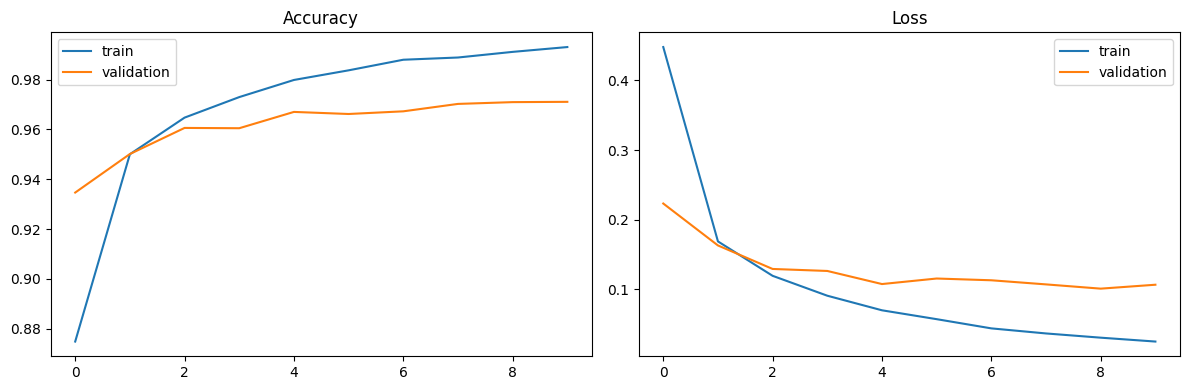

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='validation')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

We can use dropout to lower the training accuracy and increase the validation in order to avoid the model from overfitting. Dropout randomly silences 20-30% of neurons each batch during training so the network can't rely on any single pathway. We are handicapping the model's ability to memorize. This is regularization in a nutshell.

In [10]:
model2 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history2 = model2.fit(X_train.values, y_train.values,
                      validation_data=(X_test.values, y_test.values),
                      epochs=15, batch_size=128)

Epoch 1/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7918 - loss: 0.6652 - val_accuracy: 0.9225 - val_loss: 0.2500
Epoch 2/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9110 - loss: 0.3027 - val_accuracy: 0.9454 - val_loss: 0.1863
Epoch 3/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9319 - loss: 0.2333 - val_accuracy: 0.9533 - val_loss: 0.1542
Epoch 4/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9457 - loss: 0.1917 - val_accuracy: 0.9562 - val_loss: 0.1411
Epoch 5/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9493 - loss: 0.1705 - val_accuracy: 0.9604 - val_loss: 0.1264
Epoch 6/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9550 - loss: 0.1521 - val_accuracy: 0.9638 - val_loss: 0.1200
Epoch 7/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9594 - loss: 0.1373 - val_accuracy: 0.9648 - val_loss: 0.1193
Epoch 8/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9618 - loss: 0.1279 - val_accuracy: 0.

Let's improve the model using a CNN. A CNN is useful here since it fixes the actual architectural flaw. Our dense network treats pixel 405 and pixel 406 as unrelated features — it has no idea they're neighbors. A CNN learns small filters (e.g. 3×3 grids of weights) that slide across the image, detecting local patterns — an edge, a curve, a corner — wherever they appear. A loop is a loop whether it's drawn centered or shifted left. That's the translation-invariance our model needs.

In [11]:
X_train_cnn = X_train.values.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.values.reshape(-1, 28, 28, 1)

In [12]:
cnn = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_cnn = cnn.fit(X_train_cnn, y_train.values,
                      validation_data=(X_test_cnn, y_test.values),
                      epochs=10, batch_size=128)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.8887 - loss: 0.3734 - val_accuracy: 0.9729 - val_loss: 0.0889
Epoch 2/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.9725 - loss: 0.0938 - val_accuracy: 0.9798 - val_loss: 0.0650
Epoch 3/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.9804 - loss: 0.0646 - val_accuracy: 0.9826 - val_loss: 0.0522
Epoch 4/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.9828 - loss: 0.0528 - val_accuracy: 0.9881 - val_loss: 0.0412
Epoch 5/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.9864 - loss: 0.0429 - val_accuracy: 0.9870 - val_loss: 0.0431
Epoch 6/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.9888 - loss: 0.0351 - val_accuracy: 0.9870 - val_loss: 0.0448
Epoch 7/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.9893 - loss: 0.0314 - val_accuracy: 0.9881 - val_loss: 0.0389
Epoch 8/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.9917 - loss: 0.0276 - 

In [13]:
X_all = (train.drop(columns=['label']) / 255.0).values.reshape(-1, 28, 28, 1)
y_all = train['label'].values

cnn_final = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])
cnn_final.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_final.fit(X_all, y_all, epochs=7, batch_size=128)

test_cnn = (test / 255.0).values.reshape(-1, 28, 28, 1)
preds = np.argmax(cnn_final.predict(test_cnn), axis=1)

submission = pd.DataFrame({'ImageId': range(1, len(test) + 1), 'Label': preds})
submission.to_csv('submission.csv', index=False)
print(submission.head())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/7
329/329 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.9114 - loss: 0.2964
Epoch 2/7
329/329 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.9739 - loss: 0.0860
Epoch 3/7
329/329 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.9803 - loss: 0.0620
Epoch 4/7
329/329 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.9852 - loss: 0.0481
Epoch 5/7
329/329 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.9878 - loss: 0.0401
Epoch 6/7
329/329 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.9894 - loss: 0.0339
Epoch 7/7
329/329 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.9909 - loss: 0.0285
875/875 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      9
4        5      3
